In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

df = load_iris()
print(df.keys())

X = pd.DataFrame(df.data, columns= df.feature_names)
display(X.head(5))
y = pd.Series(df.target, name = 'target')

print(f'\n\nРазмер X: {X.shape}')
print('Классы: ', df.target_names)
print('\nКолличество уникальных растений: ', y.value_counts().rename(index = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}))

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2




Размер X: (150, 4)
Классы:  ['setosa' 'versicolor' 'virginica']

Колличество уникальных растений:  target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Колличество пропусков: 0
Колличество дубликатов: 1
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
142                5.8               2.7                5.1               1.9


Базовая статистика: 
                   count      mean       std  min  25%  50%  75%  max
sepal length (cm)  149.0  5.843624  0.830851  4.3  5.1  5.8  6.4  7.9
sepal width (cm)   149.0  3.059732  0.436342  2.0  2.8  3.0  3.3  4.4
petal length (cm)  149.0  3.748993  1.767791  1.0  1.6  4.3  5.1  6.9
petal width (cm)   149.0  1.194631  0.762622  0.1  0.3  1.3  1.8  2.5


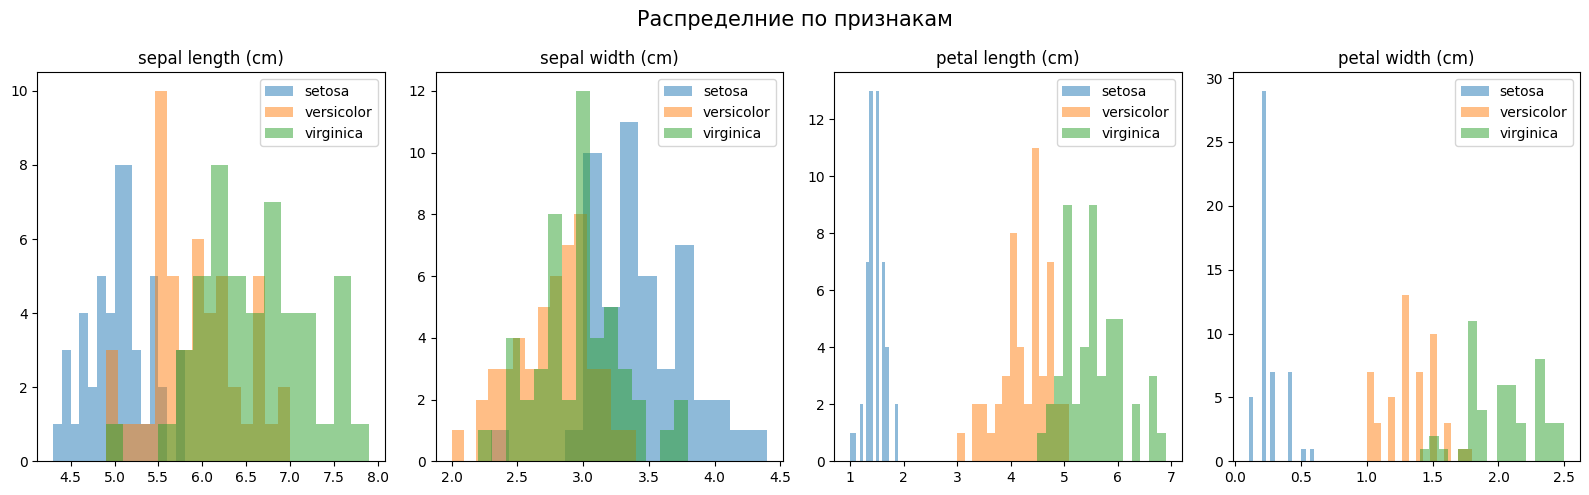

In [70]:
print('Колличество пропусков:', X.isna().sum().sum())
print('Колличество дубликатов:', X.duplicated().sum())
print(X[X.duplicated()])
X = X.drop(142)
y = y.drop(142)

print('\n\nБазовая статистика: ')
print(X.describe().T)

fig, axes = plt.subplots(1, 4, figsize = (16, 5))
for i, col in enumerate(X.columns):
    for cls in range(3):
        axes[i].hist(X[col][y == cls], alpha = 0.5, label = df.target_names[cls], bins = 15)
    axes[i].set_title(col)
    axes[i].legend(fontsize = 10)
plt.suptitle('Распределние по признакам', fontsize = (15))
plt.tight_layout()
plt.show()

In [71]:
X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size = 0.2, random_state= 42, stratify= y
)
print(X_train.shape)
print(X_test.shape)
print('Распределение классов в train:', pd.Series(y_train).value_counts().to_dict())

(119, 4)
(30, 4)
Распределение классов в train: {0: 40, 1: 40, 2: 39}


In [72]:
# Априотные вероятности
def compute_priors(y):
    a = len(y)
    classes, counts = np.unique(y, return_counts= True)
    priors = counts / a
    return (dict(zip(classes, priors.round(4))))

priors = compute_priors(y_train.values)
print("Априорные вероятности:", priors)
print("Сумма:", sum(priors.values()))
    

Априорные вероятности: {np.int64(0): np.float64(0.3361), np.int64(1): np.float64(0.3361), np.int64(2): np.float64(0.3277)}
Сумма: 0.9999


In [73]:
# Параметры распределения по каждому классу
def fit_gaussian_params(X, y):
    classes = np.unique(y)
    n_classes = len(classes)
    n_features = X.shape[1]
    means = np.zeros((n_classes, n_features))
    variances = np.zeros((n_classes, n_features))
    for i, c in enumerate(classes):        
        X_c = X[y==c]
        means[i, :] = np.mean(X_c, axis=0)
        variances[i, :] = np.var(X_c, axis=0)
    return means, variances

means, variances = fit_gaussian_params(X_train.values, y_train.values)
print("means shape:", means.shape)
print("\nМатрица средних:")
display(pd.DataFrame(means, columns=df.feature_names, index=df.target_names).round(3))
print('\nМатрица дисперсий:')
display(pd.DataFrame(variances, columns= df.feature_names, index = df.target_names).round(3))

means shape: (3, 4)

Матрица средних:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.998,3.440,1.480,0.253
versicolor,5.978,2.750,4.260,1.317
virginica,6.631,2.987,5.592,2.044



Матрица дисперсий:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.087,0.124,0.025,0.013
versicolor,0.238,0.093,0.193,0.033
virginica,0.452,0.123,0.326,0.072


In [74]:
# Вычисление log-likelihood
def gaussian_log_likelihood(x, mean, var, eps=1e-9):
    safe_var = var + eps
    log = -0.5 * np.log(2 * np.pi * safe_var) - ((x - mean)**2 / (2 * safe_var))
    log_likelihood = np.sum(log, axis = -1)
    return log_likelihood

test_x = X_train.values[0]
ll = gaussian_log_likelihood(test_x, means[0], variances[0])
print("Log-likelihood для первого объекта (класс 0):", ll)

Log-likelihood для первого объекта (класс 0): 1.4808091699537747


In [75]:
# Сбор классификатора в класс
class MyGaussianNB:
    def __init__ (self):
        self.classes_ = None
        self.log_priors_ = None 
        self.means_ = None      
        self.variances_ = None

    def fit(self, X, y):
        priors_dict = compute_priors(y)
        self.classes_ = np.array(list(priors_dict.keys()))

        priors_values = np.array(list(priors_dict.values()))
        self.log_priors_ = np.log(priors_values)

        self.means_, self.variances_ = fit_gaussian_params(X, y)

        return self

    def predict_log_proba(self, X):
        log_posteriors = np.zeros((X.shape[0], len(self.classes_)))

        for idx, c in enumerate(self.classes_):
            priors = self.log_priors_[idx]

            likelihood = gaussian_log_likelihood(X, self.means_[idx], self.variances_[idx])
            log_posteriors[:, idx] = likelihood + priors

        return log_posteriors

    def predict(self, X):
        log_probs = self.predict_log_proba(X)
        best_class = np.argmax(log_probs, axis= 1)
        pred = self.classes_[best_class]

        return pred

In [76]:
# Обучение модели

my_model = MyGaussianNB()

my_model.fit(X_train, y_train)

print("Классы:", my_model.classes_)
print("Log-прайоры:", my_model.log_priors_)
print("Форма means_:", my_model.means_.shape)

Классы: [0 1 2]
Log-прайоры: [-1.09034654 -1.09034654 -1.11565672]
Форма means_: (3, 4)


In [77]:
# Оценка качества модели
X_test_np = X_test.values
y_test_np = y_test.values

my_pred_test = my_model.predict(X_test_np)

my_metrics = {
    "accuracy": accuracy_score(y_test_np, my_pred_test),
    "precision_macro": precision_score(y_test_np, my_pred_test, average= 'macro'),
    "recall_macro": recall_score(y_test_np, my_pred_test, average= 'macro'),
    "f1_macro": f1_score(y_test_np, my_pred_test, average= 'macro'),
}

pd.Series(my_metrics).round(4)

accuracy           0.9333
precision_macro    0.9333
recall_macro       0.9333
f1_macro           0.9333
dtype: float64

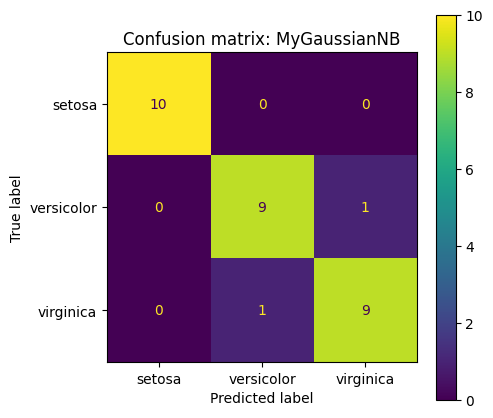

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [78]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_np, my_pred_test,
    display_labels=df.target_names,
    ax=ax
)
plt.title("Confusion matrix: MyGaussianNB")
plt.show()

print(classification_report(y_test_np, my_pred_test, target_names=df.target_names))

In [79]:
# Сравнение с scikit-learn

sk_model = GaussianNB()

sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

sk_metrics = {
    "accuracy": accuracy_score(y_test_np, sk_pred),
    "precision_macro": precision_score(y_test_np, sk_pred, average= 'macro'),
    "recall_macro": recall_score(y_test_np, sk_pred, average= 'macro'),
    "f1_macro": f1_score(y_test_np, sk_pred, average= 'macro'),
}

pd.Series(sk_metrics).round(4)

accuracy           0.9333
precision_macro    0.9333
recall_macro       0.9333
f1_macro           0.9333
dtype: float64

In [80]:
# Сводная таблица сравнения

comparison = pd.DataFrame(
    [my_metrics, sk_metrics],
    index=["my_model", "sklearn"]
)
display(comparison.round(4))

# Сравниваем оценённые средние
print("\nСредние MyGaussianNB:")
display(pd.DataFrame(my_model.means_, columns=df.feature_names, index=df.target_names).round(4))

print("\nСредние sklearn GaussianNB:")
display(pd.DataFrame(sk_model.theta_, columns=df.feature_names, index=df.target_names).round(4))

,accuracy,precision_macro,recall_macro,f1_macro
my_model,0.9333,0.9333,0.9333,0.9333
sklearn,0.9333,0.9333,0.9333,0.9333



Средние MyGaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.9975,3.4400,1.4800,0.2525
versicolor,5.9775,2.7500,4.2600,1.3175
virginica,6.6308,2.9872,5.5923,2.0436



Средние sklearn GaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.9975,3.4400,1.4800,0.2525
versicolor,5.9775,2.7500,4.2600,1.3175
virginica,6.6308,2.9872,5.5923,2.0436


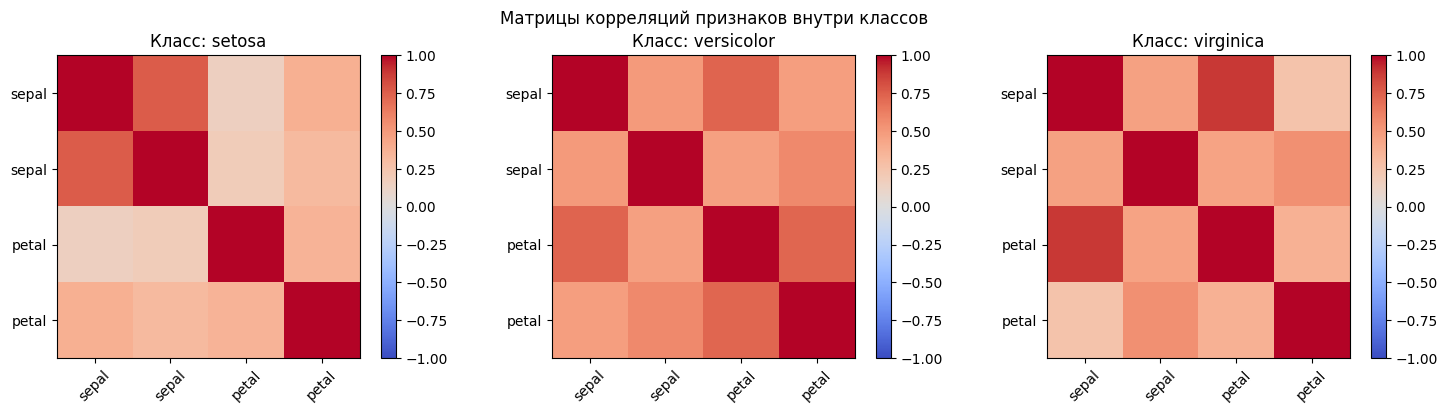

Корреляции для класса setosa:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.763,0.156,0.376
sepal width (cm),0.763,1.000,0.187,0.315
petal length (cm),0.156,0.187,1.000,0.352
petal width (cm),0.376,0.315,0.352,1.000


In [81]:
# Проверка допущения независимости
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in range(3):
    X_cls = X_train[y_train == cls]
    corr = X_cls.corr()
    im = axes[cls].imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
    axes[cls].set_title(f"Класс: {df.target_names[cls]}")
    axes[cls].set_xticks(range(4))
    axes[cls].set_yticks(range(4))
    axes[cls].set_xticklabels([f.split(' ')[0] for f in df.feature_names], rotation=45)
    axes[cls].set_yticklabels([f.split(' ')[0] for f in df.feature_names])
    plt.colorbar(im, ax=axes[cls])

plt.suptitle("Матрицы корреляций признаков внутри классов")
plt.tight_layout()
plt.show()

print("Корреляции для класса setosa:")
display(X_train[y_train == 0].corr().round(3))

1. В чём заключается 'наивное' допущение Наивного Байеса? Почему его так называют?
Допущение заключается в том, что все признаки объекта независимы друг от друга относительно целевого класса. Математически это означает, что вероятность увидеть конкретную комбинацию признаков - это просто произведение вероятностей каждого признака в отдельности. Метод называют 'наивным', так как в реальных данных (особенно биологических) признаки почти всегда коррелируют между собой (например, длина и ширина лепестка ириса сильно связаны), и модель намеренно игнорирует эти связи.
2. Почему мы используем логарифм правдоподобия вместо самого правдоподобия?
При перемножении большого количества вероятностей (чисел от 0 до 1) итоговый результат стремительно приближается к нулю, что вызывает ошибку исчезновения градиента - компьютер начинает воспринимать число как чистый ноль. Логарифмирование превращает операцию умножения в сложение, что обеспечивает высокую численную стабильность и ускоряет вычисления.
3. Почему для Гауссовского Наивного Байеса стандартизация данных не нужна?
Гауссовский Наивный Байес оценивает параметры распределения (среднее и дисперсию) для каждого признака независимо.
4. Насколько близки метрики вашей реализации к scikit-learn?
Метрики моей реализации (Accuracy: 0.9333) полностью идентичны к результатам GaussianNB из scikit-learn, что указывает на отличное выполение поставленной задачи и моей моделью.
5. Нарушается ли допущение о независимости признаков (по матрице корреляций)?
Да, в датасете Iris допущение нарушается. Матрица корреляций показывает сильную положительную связь (коэффициент >0.75  между длиной и шириной лепестка (Petal Length и Petal Width)
6. Когда Наивный Байес работает хорошо несмотря на нарушение допущения?
Наивный Байес эффективен, так как для правильной классификации ему не нужно знать точную вероятность класса. Ему достаточно того, чтобы «правильный» класс просто набрал больше баллов, чем остальные. До тех пор, пока зависимости между признаками влияют на все классы примерно одинаково и не меняют порядок лидеров, модель будет выдавать верные предсказания.
7. Сравнение Наивного Байеса и Логистической регрессии
Наивный Байес предпочтительнее на очень маленьких наборах данных, в задачах с очень высокой размерностью признаков (например, классификация текстов) и когда важна скорость обучения (оно происходит в один проход).
Логистическая регрессия лучше справляется с большими датасетами и данными, где признаки сильно коррелируют, так как она способна подбирать веса, минимизируя влияние 'дублирующих' признаков. Также регрессия лучше работает, если классы разделяются линейно.

Финальные выводы по работе
1. Сравнительный анализ с библиотечной моделью
В ходе работы была успешно реализована модель Гауссовского Наивного Байеса с нуля. Сравнение результатов с реализацией GaussianNB из библиотеки scikit-learn показало полную идентичность метрик (Accuracy: 0.9333) и рассчитанных параметров распределений. Это подтверждает математическую корректность написанных функций расчета априорных вероятностей, среднего, дисперсии и функции правдоподобия Гаусса.
2. Анализ 'наивного' допущения и корреляций
'Наивное' допущение алгоритма заключается в предположении, что все признаки независимы друг от друга внутри каждого класса. Однако построенная матрица корреляций наглядно демонстрирует нарушение этого условия:
Наблюдается сильная корреляция (0.763) между длиной и шириной чашелистика (sepal length и sepal width).
В реальных данных признаки почти всегда взаимосвязаны, что и делает алгоритм «наивным» в его допущениях.
Несмотря на нарушение условия независимости, модель показала высокую точность (93.3%). Это объясняется тем, что для классификации Байесу не обязательно знать точную вероятность — достаточно того, чтобы верный класс набрал максимальный относительный балл (логарифм вероятности) по сравнению с остальными.

3. Итог
Реализованная модель показала высокую эффективность на датасете Iris. Алгоритм Гауссовского Наивного Байеса является быстрым и надежным базовым классификатором, который, несмотря на свои упрощенные допущения, предоставляет отличную базу для сравнения более сложных моделей машинного обучения.